<a href="https://colab.research.google.com/github/VinhUIT-dotcom/housing-price-prediction/blob/main/du_bao_gia_nha_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hệ thống dự báo giá nhà từ tin rao vặt – Cần Thơ, Hậu Giang, Sóc Trăng

Notebook chạy trên **Google Colab** (Python). Làm lần lượt từng bước, chạy từng cell từ trên xuống dưới.

| Bước | Nội dung |
|---|---|
| 0 | Cài thư viện, import |
| 1 | Cấu hình + bảng địa danh |
| 2 | Thu thập dữ liệu (crawl / CSV / demo) |
| 3 | Tiền xử lý: trích xuất đặc trưng từ văn bản, chuẩn hóa địa chỉ |
| 4 | Xử lý thiếu, nhiễu, outlier + EDA |
| 5 | Trích xuất đặc trưng văn bản (TF-IDF, Word2Vec) |
| 6 | Huấn luyện 4 mô hình (Linear, Random Forest, XGBoost, LightGBM) |
| 7 | Đánh giá RMSE / MAE / R² |
| 8 | Phân tích kết quả, dự báo thử, lưu mô hình |

## Bước 0. Cài thư viện và import

In [1]:
!pip -q install geopy gensim xgboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 49.0 MB/s eta 0:00:00


In [2]:
import re, time, json, math, unicodedata, os, warnings
import numpy as np, pandas as pd, requests
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Bước 1. Cấu hình và bảng địa danh

* `DATA_SOURCE`: `"crawl"` (thu thập từ web), `"csv"` (dùng file có sẵn) hoặc `"demo"` (dữ liệu **giả lập** chỉ để kiểm tra code chạy – **không dùng để nộp kết quả**).
* Bảng `LOC` chứa quận/huyện và tọa độ **gần đúng** của trung tâm mỗi quận/huyện, dùng để chuẩn hóa địa chỉ và làm đặc trưng vị trí.
* Lưu ý: từ 2025 Hậu Giang và Sóc Trăng đã sáp nhập vào TP. Cần Thơ. Notebook vẫn giữ nhãn tỉnh **theo địa giới cũ** (dựa vào quận/huyện) để so sánh giữa 3 khu vực.

In [3]:
DATA_SOURCE = "crawl"        # "crawl" | "csv" | "demo"
MIN_SAMPLES = 5000
ALLOW_DEMO_FALLBACK = False  # False = chỉ dùng dữ liệu thật; nếu crawl ra 0 tin sẽ báo lỗi thay vì dùng dữ liệu giả
CSV_FILES = []               # ví dụ ["/content/nha_cantho.csv"]; các cột cần có: xem Bước 2
DEDUP_CONTENT = False       # False = giữ TẤT CẢ tin, kể cả tin trùng nội dung (cùng tiêu đề/giá/diện tích)
USE_ALONHADAT = True        # True: bổ sung tin từ alonhadat.com.vn (xem Bước 2D)
USE_GEOCODING = False        # True: lấy tọa độ cấp phường/xã bằng Nominatim (chậm ~1 giây/địa chỉ)

PROVINCES = ["Cần Thơ", "Hậu Giang", "Sóc Trăng"]

# district: (tỉnh, lat, lon, [alias không dấu])
LOC = {
    "Ninh Kiều": ("Cần Thơ", 10.0341, 105.7875, ["ninh kieu"]),
    "Cái Răng": ("Cần Thơ", 10.0030, 105.7660, ["cai rang"]),
    "Bình Thủy": ("Cần Thơ", 10.0730, 105.7420, ["binh thuy"]),
    "Ô Môn": ("Cần Thơ", 10.1160, 105.6270, ["o mon"]),
    "Thốt Nốt": ("Cần Thơ", 10.2500, 105.5750, ["thot not"]),
    "Phong Điền": ("Cần Thơ", 9.9960, 105.6700, ["phong dien"]),
    "Cờ Đỏ": ("Cần Thơ", 10.0900, 105.4300, ["co do"]),
    "Vĩnh Thạnh": ("Cần Thơ", 10.2000, 105.4000, ["vinh thanh"]),
    "Thới Lai": ("Cần Thơ", 10.0400, 105.5700, ["thoi lai"]),
    "Vị Thanh": ("Hậu Giang", 9.7840, 105.4700, ["vi thanh"]),
    "Ngã Bảy": ("Hậu Giang", 9.8150, 105.8270, ["nga bay"]),
    "Long Mỹ": ("Hậu Giang", 9.6780, 105.5670, ["long my"]),
    "Vị Thủy": ("Hậu Giang", 9.7700, 105.5800, ["vi thuy"]),
    "Phụng Hiệp": ("Hậu Giang", 9.8000, 105.8100, ["phung hiep"]),
    "Châu Thành (HG)": ("Hậu Giang", 9.9300, 105.8200, ["chau thanh"]),
    "Châu Thành A": ("Hậu Giang", 9.9300, 105.8600, ["chau thanh a"]),
    "TP Sóc Trăng": ("Sóc Trăng", 9.6030, 105.9730, ["thanh pho soc trang", "tp soc trang", "tx soc trang"]),
    "Vĩnh Châu": ("Sóc Trăng", 9.3370, 105.9810, ["vinh chau"]),
    "Ngã Năm": ("Sóc Trăng", 9.5520, 105.6120, ["nga nam"]),
    "Kế Sách": ("Sóc Trăng", 9.7800, 105.9700, ["ke sach"]),
    "Mỹ Tú": ("Sóc Trăng", 9.6300, 105.8200, ["my tu"]),
    "Mỹ Xuyên": ("Sóc Trăng", 9.5500, 105.9900, ["my xuyen"]),
    "Long Phú": ("Sóc Trăng", 9.6000, 106.1100, ["long phu"]),
    "Cù Lao Dung": ("Sóc Trăng", 9.6200, 106.1700, ["cu lao dung"]),
    "Thạnh Trị": ("Sóc Trăng", 9.4200, 105.7200, ["thanh tri"]),
    "Trần Đề": ("Sóc Trăng", 9.5100, 106.2000, ["tran de"]),
    "Châu Thành (ST)": ("Sóc Trăng", 9.7000, 105.8800, ["chau thanh"]),
}
CENTER = (10.0341, 105.7875)  # trung tâm Ninh Kiều

PROVINCE_KEYS = {"can tho": "Cần Thơ", "hau giang": "Hậu Giang", "soc trang": "Sóc Trăng"}


def strip_acc(s):
    s = unicodedata.normalize("NFD", str(s).lower().replace("đ", "d"))
    return "".join(c for c in s if unicodedata.category(c) != "Mn")


def norm_loc_text(s):
    return " " + re.sub(r"[^a-z0-9]+", " ", strip_acc(s)).strip() + " "


def haversine(lat1, lon1, lat2, lon2):
    p = math.pi / 180
    a = (np.sin((lat2 - lat1) * p / 2) ** 2 +
         np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin((lon2 - lon1) * p / 2) ** 2)
    return 12742 * np.arcsin(np.sqrt(a))

## Bước 2. Thu thập dữ liệu (≥ 5.000 tin)

Có 3 cách, chọn bằng `DATA_SOURCE`:

* **2A – Crawl** từ API công khai của Chợ Tốt (nhatot.com), danh mục nhà ở. Code có sleep giữa các request. Bạn nên kiểm tra điều khoản sử dụng của trang trước khi crawl và chỉ dùng cho mục đích học tập.
  * Muốn lọc chính xác theo tỉnh: mở nhatot.com, chọn tỉnh, bấm F12 → Network, tìm request `ad-listing`, copy giá trị `region_v2` điền vào `REGION_CODES`. Nếu để `None`, code tìm theo từ khóa tên tỉnh rồi lọc lại theo quận/huyện.
  * Nếu crawl chưa đủ 5.000 tin, hãy bổ sung nguồn khác (tự lưu CSV) và đưa vào `CSV_FILES`.
* **2B – Demo**: dữ liệu giả lập để thử code.
* **2C – CSV có sẵn**: cần các cột `title, description, price_vnd` và (nếu có) `area_raw, rooms_raw, floors_raw, width_raw, region_name, area_name, ward_name, address`. Đặt `DATA_SOURCE = "csv"`.

In [4]:
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/124 Safari/537.36",
           "Accept": "application/json"}
API_URL = "https://gateway.chotot.com/v1/public/ad-listing"
REGION_CODES = {"Cần Thơ": None, "Hậu Giang": None, "Sóc Trăng": None}
CATEGORIES = [1020]   # 1020 = nhà ở trên Chợ Tốt; có thể thêm mã danh mục khác nếu cần thêm dữ liệu


def crawl_chotot(province, region_code=None, cg=1020, max_items=4000, sleep=0.8, max_retry=3):
    rows, offset = [], 0
    while len(rows) < max_items:
        params = {"cg": cg, "limit": 50, "o": offset, "st": "s,k"}
        if region_code:
            params["region_v2"] = region_code
        else:
            params["q"] = province
        ads = None
        for attempt in range(max_retry):
            try:
                r = requests.get(API_URL, params=params, headers=HEADERS, timeout=20)
                if r.status_code == 200:
                    ads = r.json().get("ads", [])
                    break
                print("HTTP", r.status_code, "- thử lại")
            except Exception as e:
                print("Lỗi:", e)
            time.sleep(2 * (attempt + 1))
        if not ads:
            break
        for a in ads:
            rows.append({
                "ad_id": a.get("ad_id"), "title": a.get("subject"), "description": a.get("body"),
                "price_vnd": a.get("price"), "area_raw": a.get("size"), "rooms_raw": a.get("rooms"),
                "floors_raw": a.get("floors"), "width_raw": a.get("width"),
                "region_name": a.get("region_name"), "area_name": a.get("area_name"),
                "ward_name": a.get("ward_name"), "address": a.get("address") or a.get("street_name"),
                "lat_raw": a.get("latitude"), "lon_raw": a.get("longitude"),
                "category": cg, "list_time": a.get("list_time")})
        offset += 50
        if offset % 500 == 0:
            print(f"{province}: đã lấy {len(rows)} tin")
        time.sleep(sleep)
    return pd.DataFrame(rows)


def make_demo(n=6000, seed=42):
    # DỮ LIỆU GIẢ LẬP - chỉ để kiểm tra pipeline
    rng = np.random.default_rng(seed)
    base = {"Ninh Kiều": 45, "Cái Răng": 28, "Bình Thủy": 30, "Ô Môn": 14, "Thốt Nốt": 12, "Phong Điền": 13,
            "Vị Thanh": 14, "Ngã Bảy": 13, "TP Sóc Trăng": 22, "Vĩnh Châu": 10, "Ngã Năm": 8}
    names = list(LOC)
    w = np.array([6 if d == "Ninh Kiều" else 3 if d in ("Cái Răng", "Bình Thủy", "TP Sóc Trăng") else 1 for d in names], float)
    w /= w.sum()
    streets = ["Nguyễn Văn Cừ", "Trần Hưng Đạo", "Mậu Thân", "30 Tháng 4", "Quốc lộ 1A", "Võ Văn Kiệt", "Hùng Vương", "Lê Hồng Phong"]
    rows = []
    for i in range(n):
        d = rng.choice(names, p=w)
        prov = LOC[d][0]
        width = round(float(rng.uniform(3, 9)), 1)
        area = int(round(width * rng.uniform(10, 30)))
        floors = int(rng.choice([1, 2, 3, 4], p=[.4, .3, .2, .1]))
        bed = int(min(8, rng.integers(1, 3) + floors - 1))
        mt = rng.random() < .35
        legal = rng.random() < .8
        ppm = base.get(d, 6)
        price = area * ppm * (1 + .08 * (floors - 1)) * (1.3 if mt else .8) * (1.05 if legal else .9) * np.exp(rng.normal(0, .12)) / 1000
        if rng.random() < .01:
            price *= 10
        parts = [f"Bán nhà {'mặt tiền' if mt else 'hẻm xe hơi'} đường {rng.choice(streets)}", f"diện tích {area}m2"]
        if rng.random() > .2: parts.append(f"ngang {width}m")
        if rng.random() > .2: parts.append(f"{floors} tầng")
        if rng.random() > .25: parts.append(f"{bed} phòng ngủ")
        parts.append("sổ hồng riêng" if legal else "giấy tay")
        parts += list(rng.choice(["gần chợ", "gần trường học", "gần bệnh viện", "khu dân cư đông", "view sông", "nhà mới xây", "nội thất đẹp"], size=2, replace=False))
        parts.append(f"giá {price:.2f} tỷ")
        rows.append({"ad_id": i, "title": parts[0], "description": ", ".join(parts[1:]), "price_vnd": price * 1e9,
                     "area_raw": area if rng.random() < .7 else np.nan, "rooms_raw": np.nan, "floors_raw": np.nan,
                     "width_raw": np.nan, "region_name": prov, "area_name": d,
                     "ward_name": f"Phường {rng.integers(1, 12)}", "address": rng.choice(streets)})
    return pd.DataFrame(rows)

### 2D. Bổ sung tin từ alonhadat.com.vn (giữ nguyên cấu trúc cũ)

* Crawl thêm tin **bán nhà** từ alonhadat và đổi về **đúng các cột** của Chợ Tốt nên các bước sau **không phải sửa**.
* Parser đọc theo **nhãn chữ trên thẻ tin** ("Giá:", "Diện tích:", "KT:", "x tầng", "x phòng ngủ") chứ không phụ thuộc tên class CSS, nên ít bị hỏng khi trang đổi giao diện.
* Trang hiện ghi 2 địa chỉ: địa chỉ mới (sau sáp nhập, "Cần Thơ") và địa chỉ **(cũ)** có quận/huyện + tỉnh cũ. Notebook dùng địa chỉ (cũ) để gán đúng Cần Thơ / Hậu Giang / Sóc Trăng và quận/huyện.
* Kết quả lưu cộng dồn ở `data/raw_alonhadat.csv`, có cột `source`.

In [5]:
from bs4 import BeautifulSoup

# URL trang 1 của danh sách "bán nhà". Sau sáp nhập, trang có thể gom cả 3 khu vực vào "Cần Thơ"
# (địa chỉ cũ vẫn ghi Hậu Giang/Sóc Trăng) -> chỉ cần crawl "Cần Thơ". Hai URL còn lại là dự đoán, sai thì tự bị bỏ qua.
ALONHADAT_URLS = {
    "Cần Thơ": "https://alonhadat.com.vn/can-ban-nha/can-tho",   # danh sách đã gồm cả tin có địa chỉ (cũ) Hậu Giang / Sóc Trăng
}
ALO_PAGE_FMTS = [      # notebook tự thử lần lượt ở trang 2, dùng kiểu nào ra tin mới; thêm kiểu của bạn lên đầu nếu biết
    "{base}/trang--{n}.html", "{base}/trang--{n}", "{base}/trang-{n}.html", "{base}/trang-{n}",
    "{base}?page={n}", "{base}?p={n}", "{base}/p{n}", "{base}/page-{n}", "{base}/page/{n}", "{base}/{n}"]
ALO_MAX_PAGES = 150
ALO_SLEEP = 1.5                            # giây giữa các request, đừng giảm quá thấp

ADDR_RE = re.compile(r".+,\s*(Cần Thơ|Hậu Giang|Sóc Trăng)\s*(\(cũ\))?\s*$")


def alo_page_url(base, n, fmt=None):
    return base if n == 1 else fmt.format(base=base, n=n)


def alo_price(t, area):
    """t: văn bản đã bỏ dấu, ví dụ '3 ty 500 trieu' hoặc '40 trieu/m2'."""
    ms = list(re.finditer(r"(\d+(?:[.,]\d+)?)\s*(ty|trieu|nghin)", t))
    if not ms:
        return np.nan                       # 'Thỏa thuận', 'Liên hệ'...
    unit = {"ty": 1e9, "trieu": 1e6, "nghin": 1e3}
    val = sum(float(m.group(1).replace(",", ".")) * unit[m.group(2)] for m in ms)
    if re.search(r"/\s*m", t[ms[-1].end():ms[-1].end() + 6]):
        return val * area if area == area else np.nan
    return val


GIA_RE = re.compile(r"^\s*Giá\s*:", re.I)
DT_RE = re.compile(r"^\s*Diện tích\s*:", re.I)


def _row_of(node):
    """Phần tử NGẮN (<=150 ký tự) chứa cả nhãn 'Giá:' và 'Diện tích:' = dòng thông số của một tin."""
    best = None
    for d in [node] + node.find_all(True):
        if d.find(string=GIA_RE) is not None and d.find(string=DT_RE) is not None \
                and len(d.get_text(" ", strip=True)) <= 150:
            if best is None or len(d.get_text()) < len(best.get_text()):
                best = d
    return best


def alo_cards(soup):
    """Trả về [(thẻ tin, link, dòng thông số)]. Thẻ tin = tổ tiên nhỏ nhất của link 'Xem chi tiết' chứa 1 dòng thông số."""
    seen, cards = set(), []
    anchors = [a for a in soup.find_all("a", href=True) if re.search(r"Xem chi ti", a.get_text(" "), re.I)]
    if not anchors:
        anchors = [a for a in soup.find_all("a", href=True) if re.search(r"-\d{5,}\.html?$", a["href"])]
    for a in anchors:
        node, row = a, None
        while node.parent is not None and node.name not in ("body", "html", "[document]"):
            row = _row_of(node)
            if row is not None:
                break
            node = node.parent
        if row is None or id(node) in seen:
            continue
        rows_in = [d for d in [node] + node.find_all(True)
                   if d.find(string=GIA_RE) is not None and d.find(string=DT_RE) is not None
                   and len(d.get_text(" ", strip=True)) <= 150]
        if len(rows_in) > 1 and node.get_text(" ").count("Diện tích:") > 3:   # thẻ gom quá nhiều tin
            continue
        seen.add(id(node))
        cards.append((node, a, row))
    return cards


def alo_parse(html, province):
    soup = BeautifulSoup(html, "html.parser")
    out = []
    for card, more, row in alo_cards(soup):
        text = card.get_text(" ", strip=True)
        t = strip_acc(text)
        href = more.get("href", "")
        m = re.search(r"(\d{5,})", href)
        ad_id = "alo_" + (m.group(1) if m else href)
        tl = card.find("a", href=True)
        title = tl.get_text(" ", strip=True) if tl is not None else ""
        brief = more.parent.get_text(" ", strip=True) if more.parent is not None else ""
        brief = re.sub(r"<<\s*Xem chi ti.*$", "", brief, flags=re.I).strip()

        t = strip_acc(text.replace(brief, " ").replace(title, " "))   # không để mô tả làm nhiễu các nhãn
        tr = strip_acc(row.get_text(" ", strip=True))                  # dòng 'Giá: ... Diện tích: ... KT: ...'
        am = re.search(r"dien tich:\s*(\d+(?:[.,]\d+)?)", tr)
        area = float(am.group(1).replace(",", ".")) if am else np.nan
        pm = re.search(r"gia:\s*(.+?)\s*dien tich:", tr)
        price = alo_price(pm.group(1), area) if pm else np.nan
        km = re.search(r"kt:\s*(\d+(?:[.,]\d+)?)\s*x\s*(\d+(?:[.,]\d+)?)", tr) or re.search(r"kt:\s*(\d+(?:[.,]\d+)?)\s*x\s*(\d+(?:[.,]\d+)?)", t)
        width = min(float(km.group(1).replace(",", ".")), float(km.group(2).replace(",", "."))) if km else np.nan
        fm = re.search(r"(\d+)\s*tang", t)
        bm = re.search(r"(\d+)\s*phong ngu", t)

        addrs = [s.strip() for s in card.find_all(string=True)
                 if s.parent.name != "a" and len(s.strip()) < 150 and ADDR_RE.match(s.strip())]
        old = next((s for s in addrs if "(cũ)" in s), None)
        new = next((s for s in addrs if "(cũ)" not in s), None)
        ref = old or new or ""
        prov_m = re.search(r"(Cần Thơ|Hậu Giang|Sóc Trăng)\s*(\(cũ\))?\s*$", ref)
        wm = re.search(r"(?:Phường|Xã|Thị trấn)\s+[^,]+", old or new or "")
        out.append({
            "ad_id": ad_id, "title": title, "description": brief,
            "price_vnd": price, "area_raw": area,
            "rooms_raw": int(bm.group(1)) if bm else np.nan,
            "floors_raw": int(fm.group(1)) if fm else np.nan,
            "width_raw": width,
            "region_name": prov_m.group(1) if prov_m else province,   # tỉnh theo địa giới CŨ
            "area_name": ref,                                          # chứa quận/huyện cũ -> locate() dùng
            "ward_name": wm.group(0) if wm else np.nan,
            "address": " | ".join(addrs), "lat_raw": np.nan, "lon_raw": np.nan,
            "category": "alonhadat", "list_time": np.nan, "source": "alonhadat"})
    return out, len(out)


def alo_get(url, tries=3):
    for attempt in range(tries):
        try:
            r = requests.get(url, headers=HEADERS, timeout=20)
            if r.status_code == 200:
                return r.text
            if r.status_code in (404, 403):
                return None
        except Exception as e:
            print("Lỗi:", e)
        time.sleep(2 * (attempt + 1))
    return None


def crawl_alonhadat(province, base, max_pages=ALO_MAX_PAGES, sleep=ALO_SLEEP):
    rows, ids, fmt, empty = [], set(), None, 0
    for n in range(1, max_pages + 1):
        html, new = None, []
        for f in ([fmt] if fmt else ([None] if n == 1 else ALO_PAGE_FMTS)):
            html = alo_get(alo_page_url(base, n, f))
            if html is None:
                continue
            parsed, _ = alo_parse(html, province)
            new = [p for p in parsed if p["ad_id"] not in ids]
            if new:
                if n == 2:
                    fmt = f
                    print("Kiểu phân trang đúng:", f)
                break
            time.sleep(0.5)
        if n > 1 and html is not None:
            print(f"  trang {n}: đọc {len(parsed)} tin, mới {len(new)}, thiếu giá {sum(pd.isna(p['price_vnd']) for p in new)}")
        if not new and n > 2 and html is not None and empty < 1:
            empty += 1
            time.sleep(sleep)
            continue
        if not new:
            if n == 1 and html is not None:
                os.makedirs("data", exist_ok=True)
                open("data/alo_page1.html", "w", encoding="utf-8").write(html)
                print("Trang 1 không có tin. Đã lưu HTML ở data/alo_page1.html")
            elif n == 2:
                print("Không kiểu phân trang nào đúng. Bấm sang trang 2 trên web, copy URL gửi cho trợ lý.")
            else:
                print(f"Hết tin ở trang {n}")
            break
        ids.update(p["ad_id"] for p in new)
        rows += new
        if n % 10 == 0:
            print(f"alonhadat {province}: trang {n}, {len(rows)} tin")
        time.sleep(sleep)
    return pd.DataFrame(rows)


extra = pd.DataFrame()
if USE_ALONHADAT:
    parts = []
    for p, u in ALONHADAT_URLS.items():
        if not u:
            continue
        print("Crawl alonhadat -", p)
        parts.append(crawl_alonhadat(p, u))
    os.makedirs("data", exist_ok=True)
    old = pd.read_csv("data/raw_alonhadat.csv") if os.path.exists("data/raw_alonhadat.csv") else pd.DataFrame()
    extra = pd.concat([old] + parts, ignore_index=True)
    if len(extra):
        extra = extra.drop_duplicates("ad_id")
        extra.to_csv("data/raw_alonhadat.csv", index=False)
    print("Số tin alonhadat (cộng dồn, bỏ trùng):", len(extra))
    if len(extra):
        print(extra[["title", "price_vnd", "area_raw", "region_name", "area_name"]].head())


Crawl alonhadat - Cần Thơ
Kiểu phân trang đúng: {base}/trang-{n}
  trang 2: đọc 20 tin, mới 20, thiếu giá 0
  trang 3: đọc 20 tin, mới 20, thiếu giá 0
  trang 4: đọc 20 tin, mới 20, thiếu giá 0
  trang 5: đọc 20 tin, mới 20, thiếu giá 0
  trang 6: đọc 20 tin, mới 20, thiếu giá 0
  trang 7: đọc 20 tin, mới 20, thiếu giá 0
  trang 8: đọc 20 tin, mới 20, thiếu giá 1
  trang 9: đọc 20 tin, mới 20, thiếu giá 0
  trang 10: đọc 20 tin, mới 20, thiếu giá 0
alonhadat Cần Thơ: trang 10, 200 tin
  trang 11: đọc 20 tin, mới 20, thiếu giá 0
  trang 12: đọc 20 tin, mới 20, thiếu giá 0
  trang 13: đọc 20 tin, mới 20, thiếu giá 0
  trang 14: đọc 20 tin, mới 20, thiếu giá 0
  trang 15: đọc 20 tin, mới 20, thiếu giá 0
  trang 16: đọc 20 tin, mới 20, thiếu giá 0
  trang 17: đọc 20 tin, mới 20, thiếu giá 0
  trang 18: đọc 20 tin, mới 20, thiếu giá 0
  trang 19: đọc 20 tin, mới 20, thiếu giá 0
  trang 20: đọc 20 tin, mới 20, thiếu giá 0
alonhadat Cần Thơ: trang 20, 400 tin
  trang 21: đọc 20 tin, mới 20, t

In [6]:
raw = pd.DataFrame()
USING_DEMO = False
if DATA_SOURCE == "crawl":
    parts = []
    for p in PROVINCES:
        for cg in CATEGORIES:
            print("Crawl", p, "- danh mục", cg, "...")
            parts.append(crawl_chotot(p, REGION_CODES.get(p), cg=cg))
    raw = pd.concat(parts, ignore_index=True)
    # Cộng dồn với các lần crawl trước (chỉ dữ liệu Chợ Tốt thật), bỏ trùng theo ad_id
    if os.path.exists("data/raw_chotot.csv"):
        raw = pd.concat([pd.read_csv("data/raw_chotot.csv"), raw], ignore_index=True)
    if "ad_id" in raw and len(raw):
        raw = raw.drop_duplicates("ad_id")
        os.makedirs("data", exist_ok=True)
        raw.to_csv("data/raw_chotot.csv", index=False)
    print("Số tin Chợ Tốt (đã cộng dồn, bỏ trùng):", len(raw))
    if len(raw) == 0 and ALLOW_DEMO_FALLBACK:
        print("!!! CẢNH BÁO: crawl không có dữ liệu -> dùng DỮ LIỆU GIẢ LẬP. Không dùng kết quả này để báo cáo.")
        raw = make_demo()
        USING_DEMO = True
elif DATA_SOURCE == "demo":
    print("!!! Đang dùng DỮ LIỆU GIẢ LẬP (demo).")
    raw = make_demo()
    USING_DEMO = True

if USE_ALONHADAT and len(extra):
    raw = pd.concat([raw, extra], ignore_index=True)   # thêm tin alonhadat, các cột đã khớp với Chợ Tốt

for f in CSV_FILES:
    raw = pd.concat([raw, pd.read_csv(f)], ignore_index=True)

if len(raw) == 0:
    raise RuntimeError("Không có dữ liệu thật. Kiểm tra REGION_CODES (đặt None hoặc lấy region_v2 bằng F12), "
                       "hoặc thêm CSV vào CSV_FILES.")
print("NGUỒN DỮ LIỆU:", "GIẢ LẬP (demo)" if USING_DEMO else "THẬT (Chợ Tốt / CSV)")

os.makedirs("data", exist_ok=True)
raw.to_csv("data/raw_listings.csv", index=False)
print("Tổng số tin thô:", len(raw))
if "source" in raw:
    print(raw["source"].fillna("chotot").value_counts())
if len(raw) < MIN_SAMPLES:
    print(f"Chưa đủ {MIN_SAMPLES} tin, hãy crawl thêm hoặc thêm CSV vào CSV_FILES.")
raw.head()

Crawl Cần Thơ - danh mục 1020 ...
Crawl Hậu Giang - danh mục 1020 ...
Crawl Sóc Trăng - danh mục 1020 ...
Số tin Chợ Tốt (đã cộng dồn, bỏ trùng): 401
NGUỒN DỮ LIỆU: THẬT (Chợ Tốt / CSV)
Tổng số tin thô: 2873
source
alonhadat    2472
chotot        401
Name: count, dtype: int64
Chưa đủ 5000 tin, hãy crawl thêm hoặc thêm CSV vào CSV_FILES.


,ad_id,title,description,price_vnd,area_raw,rooms_raw,floors_raw,width_raw,region_name,area_name,ward_name,address,lat_raw,lon_raw,category,list_time,source
0,179169617,nhà cấp 4 ở cần thơ,Dự án: \nThông tin chi tiết: Cần bán Nhà Cấp 4...,1.700000e+09,65.0,2.0,1.0,4.0,Cần Thơ,Quận Ninh Kiều,Phường An Khánh,Đường Trần Nam Phú,10.033997,105.75952,1020,1.790930e+12,NaN
1,178699692,"Nhà MT lộ ôtô 4m , Phong Điền , Tp. Cần Thơ",Dự án: \nThông tin chi tiết: Nhà mặt tiền lộ b...,1.450000e+09,226.0,3.0,1.0,6.3,Cần Thơ,Huyện Phong Điền,Xã Nhơn Ái,Đê Bao Nhơn Ái,9.989778,105.65885,1020,1.790990e+12,NaN
2,177165891,NHÀ 2 LẦU - KHU ĐẠI HỌC Y DƯỢC CẦN THƠ,☘️ NHÀ 1 TRỆT 2 LẦU KHU DÂN CƯ ĐẠI HỌC Y DƯỢC ...,5.700000e+09,64.0,4.0,2.0,4.0,Cần Thơ,Quận Ninh Kiều,Phường An Khánh,Thành phố cần thơ,10.031184,105.75565,1020,1.790928e+12,NaN
3,175663849,"Nhà hoàn công mặt tiền Đặng Văn Dầy, Bình Thuỷ...",Dự án: \nThông tin chi tiết: 🏧BÁN NHÀ CẤP 4 MẶ...,4.600000e+09,486.0,3.0,0.0,6.0,Cần Thơ,Quận Bình Thuỷ,Phường Bình Thủy,Đường Đặng Văn Dầy,10.072307,105.74513,1020,1.790989e+12,NaN
4,175726131,NHÀ TRỆT LẦU - KHU ĐẠI HỌC Y DƯỢC CẦN THƠ,☘️ BÁN NHÀ TRỆT LẦU ĐẸP - KDC ĐẠI HỌC Y DƯỢC C...,5.200000e+09,64.0,3.0,2.0,4.0,Cần Thơ,Quận Ninh Kiều,Phường An Khánh,Quận Ninh Kiều,10.031184,105.75565,1020,1.790777e+12,NaN


## Bước 3. Tiền xử lý: trích xuất đặc trưng định lượng và chuẩn hóa địa chỉ

* Dùng **regex** để lấy *diện tích, số phòng ngủ, số tầng, chiều rộng mặt tiền* từ văn bản; ưu tiên trường có cấu trúc nếu có.
* **Chống rò rỉ nhãn:** mô tả thường chứa luôn giá ("giá 3 tỷ"), nên phải xóa mọi cụm tiền ra khỏi văn bản trước khi đưa vào TF-IDF.
* Địa chỉ được chuẩn hóa về **Tỉnh → Quận/Huyện → Phường/Xã** và gán tọa độ.

In [7]:
def to_f(s):
    return float(str(s).replace(",", "."))

NUM = r"(\d+(?:[.,]\d+)?)"
DIM = re.compile(NUM + r"\s*m?\s*[x*×]\s*" + NUM)

def extract_area(t):
    for m in re.finditer(NUM + r"\s*(?:m2|m²|m\^2|met vuong)", t):
        v = to_f(m.group(1))
        if 10 <= v <= 5000:
            return v
    m = DIM.search(t)
    if m:
        v = to_f(m.group(1)) * to_f(m.group(2))
        if 10 <= v <= 5000:
            return v
    return np.nan

def extract_frontage(t):
    m = re.search(r"(?:ngang|mat tien|mt)\s*:?\s*" + NUM + r"\s*m\b", t)
    if m:
        v = to_f(m.group(1))
    else:
        m = DIM.search(t)
        v = min(to_f(m.group(1)), to_f(m.group(2))) if m else np.nan
    return v if 2 <= v <= 30 else np.nan

def extract_bedrooms(t):
    m = re.search(r"(\d+)\s*(?:pn|phong ngu)", t)
    if m:
        v = int(m.group(1))
        return v if 1 <= v <= 15 else np.nan
    return np.nan

def extract_floors(t):
    m = re.search(r"(\d+)\s*lau", t)
    if m:
        v = int(m.group(1)) + 1
    else:
        m = re.search(r"(\d+)\s*tang", t)
        if m:
            v = int(m.group(1))
        elif re.search(r"cap 4|nha tret|1 tret", t):
            v = 1
        else:
            return np.nan
    return v if 1 <= v <= 10 else np.nan

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"https?://\S+", " ", s)
    s = re.sub(r"\d{9,11}", " ", s)                                          # số điện thoại
    s = re.sub(r"\d+(?:[.,]\d+)?\s*(?:tỷ|ty|triệu|trieu|tr)\b", " ", s)      # bỏ giá
    s = re.sub(r"\bgiá\b[^,.;]{0,25}", " ", s)
    s = re.sub(r"\d+(?:[.,]\d+)?", " ", s)                                   # bỏ số còn lại (đã trích riêng)
    s = re.sub(r"[^\w\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def _s(v):
    return "" if v is None or (isinstance(v, float) and math.isnan(v)) else str(v)

def locate(row):
    hint = norm_loc_text(_s(row.get("region_name")))
    hp = [v for k, v in PROVINCE_KEYS.items() if " " + k + " " in hint]
    if _s(row.get("region_name")).strip() and not hp:
        return None, None            # vùng khác 3 khu vực mục tiêu
    for cols in (["area_name"], ["address"], ["title"]):
        t = norm_loc_text(" ".join(_s(row.get(c)) for c in cols))
        found = []
        for d, (prov, _, _, aliases) in LOC.items():
            for a in aliases:
                if " " + a + " " in t:
                    found.append((len(a), d, prov))
        if not found:
            continue
        mx = max(f[0] for f in found)
        found = [f for f in found if f[0] == mx]
        if len(found) > 1 and hp:
            found = [f for f in found if f[2] in hp] or found
        if len(found) == 1:
            return found[0][2], found[0][1]
    return None, None

def clean_ward(w):
    w = str(w or "").strip()
    w = re.sub(r"^(phường|xã|thị trấn|p\.|x\.|tt\.)\s*", "", w, flags=re.I).strip().title()
    return w if w and w.lower() != "nan" else "Không rõ"

In [8]:
def build_dataset(raw):
    df = raw.copy()
    for c in ["title", "description"]:
        df[c] = df[c].fillna("").astype(str)
    df["full_text"] = df["title"] + ". " + df["description"]

    loc = df.apply(locate, axis=1, result_type="expand")
    df["province"], df["district"] = loc[0], loc[1]
    df = df.dropna(subset=["district"]).copy()
    tn = df["full_text"].map(strip_acc)

    num = lambda c: pd.to_numeric(df[c], errors="coerce") if c in df else pd.Series(np.nan, index=df.index)
    df["area_m2"] = num("area_raw").where(lambda s: s > 0).fillna(tn.map(extract_area))
    df["bedrooms"] = num("rooms_raw").where(lambda s: (s >= 1) & (s <= 15)).fillna(tn.map(extract_bedrooms))
    df["floors"] = num("floors_raw").where(lambda s: (s >= 1) & (s <= 10)).fillna(tn.map(extract_floors))
    df["frontage"] = num("width_raw").where(lambda s: (s >= 2) & (s <= 30)).fillna(tn.map(extract_frontage))

    df["price_ty"] = pd.to_numeric(df["price_vnd"], errors="coerce") / 1e9
    df["ward"] = df["ward_name"].map(clean_ward) if "ward_name" in df else "Không rõ"
    df["text_clean"] = df["full_text"].map(clean_text)
    df["text_len"] = df["text_clean"].str.len()
    df["n_words"] = df["text_clean"].str.split().str.len()

    df["lat"] = df["district"].map(lambda d: LOC[d][1])
    df["lon"] = df["district"].map(lambda d: LOC[d][2])
    # Chợ Tốt có sẵn tọa độ từng tin -> dùng thay cho tọa độ trung tâm quận/huyện (nếu hợp lệ, trong vùng ĐBSCL)
    la, lo = num("lat_raw"), num("lon_raw")
    ok = la.between(9.0, 10.6) & lo.between(105.0, 106.5)
    df["lat"] = la.where(ok, df["lat"])
    df["lon"] = lo.where(ok, df["lon"])
    df["has_gps"] = ok.astype(int)
    return df

df = build_dataset(raw)
print("Sau khi lọc theo khu vực mục tiêu:", len(df))
print(df["province"].value_counts())
df[["title", "province", "district", "ward", "area_m2", "bedrooms", "floors", "frontage", "price_ty"]].head()

Sau khi lọc theo khu vực mục tiêu: 2821
province
Cần Thơ      2788
Sóc Trăng      20
Hậu Giang      13
Name: count, dtype: int64


,title,province,district,ward,area_m2,bedrooms,floors,frontage,price_ty
0,nhà cấp 4 ở cần thơ,Cần Thơ,Ninh Kiều,An Khánh,65.0,2.0,1.0,4.0,1.70
1,"Nhà MT lộ ôtô 4m , Phong Điền , Tp. Cần Thơ",Cần Thơ,Phong Điền,Nhơn Ái,226.0,3.0,1.0,6.3,1.45
2,NHÀ 2 LẦU - KHU ĐẠI HỌC Y DƯỢC CẦN THƠ,Cần Thơ,Ninh Kiều,An Khánh,64.0,4.0,2.0,4.0,5.70
3,"Nhà hoàn công mặt tiền Đặng Văn Dầy, Bình Thuỷ...",Cần Thơ,Bình Thủy,Bình Thủy,486.0,3.0,1.0,6.0,4.60
4,NHÀ TRỆT LẦU - KHU ĐẠI HỌC Y DƯỢC CẦN THƠ,Cần Thơ,Ninh Kiều,An Khánh,64.0,3.0,2.0,4.0,5.20


In [9]:
# (Tùy chọn) Tọa độ cấp phường/xã bằng geocoding, có cache
if USE_GEOCODING:
    from geopy.geocoders import Nominatim
    geo = Nominatim(user_agent="house-price-student-project")
    cache_path = "data/geo_cache.json"
    cache = json.load(open(cache_path)) if os.path.exists(cache_path) else {}
    keys = df[["ward", "district", "province"]].drop_duplicates().itertuples(index=False)
    for ward, dist, prov in keys:
        k = f"{ward}|{dist}|{prov}"
        if k in cache or ward == "Không rõ":
            continue
        try:
            r = geo.geocode(f"{ward}, {dist.split(' (')[0]}, {prov}, Việt Nam", timeout=10)
            cache[k] = [r.latitude, r.longitude] if r else None
        except Exception:
            cache[k] = None
        time.sleep(1.1)
        json.dump(cache, open(cache_path, "w"))
    def fix(r):
        v = cache.get(f"{r.ward}|{r.district}|{r.province}")
        return pd.Series(v if v else [r.lat, r.lon])
    df[["lat", "lon"]] = df.apply(fix, axis=1).values

df["dist_center_km"] = haversine(CENTER[0], CENTER[1], df["lat"], df["lon"])

## Bước 4. Xử lý thiếu, nhiễu, outlier và khám phá dữ liệu

* Loại tin trùng, giá/diện tích vô lý.
* **Outlier:** loại theo IQR của log(giá/m²) *trong từng quận/huyện* (quận ít hơn 30 tin dùng ngưỡng chung).
* **Giá trị thiếu** (phòng ngủ, tầng, mặt tiền) được điền *median* bên trong pipeline ở Bước 6, kèm cờ "đã thiếu", để không rò rỉ dữ liệu test.

In [10]:
n0 = len(df)
if DEDUP_CONTENT:
    df = df.drop_duplicates(subset=["title", "price_ty", "area_m2"])
print("Tin trùng nội dung (giữ lại, không xóa):", int(df.duplicated(subset=["title", "price_ty", "area_m2"]).sum()))
df = df.dropna(subset=["price_ty", "area_m2"])
df = df[(df.price_ty >= 0.1) & (df.price_ty <= 100) & (df.area_m2 >= 15) & (df.area_m2 <= 1000)].copy()
df["ppm2"] = df.price_ty * 1000 / df.area_m2          # triệu đồng / m²
df["log_ppm2"] = np.log(df.ppm2)

def iqr_bounds(s, k=2.0):
    q1, q3 = s.quantile([.25, .75]); i = q3 - q1
    return q1 - k * i, q3 + k * i

g = iqr_bounds(df.log_ppm2)
lo = df.groupby("district").log_ppm2.transform(lambda s: iqr_bounds(s)[0] if len(s) >= 30 else g[0])
hi = df.groupby("district").log_ppm2.transform(lambda s: iqr_bounds(s)[1] if len(s) >= 30 else g[1])
n1 = len(df)
df = df[(df.log_ppm2 >= lo) & (df.log_ppm2 <= hi)].copy()
df["log_area"] = np.log(df.area_m2)
print(f"{n0} -> {n1} (lọc giá/diện tích/trùng) -> {len(df)} (bỏ outlier)")
print("Tỉ lệ thiếu:\n", df[["area_m2", "bedrooms", "floors", "frontage"]].isna().mean().round(3))
if len(df) < MIN_SAMPLES:
    print(f"Lưu ý: còn {len(df)} mẫu < {MIN_SAMPLES}, cần bổ sung dữ liệu cho đủ yêu cầu.")
df.describe().T[["count", "mean", "std", "min", "50%", "max"]]

Tin trùng nội dung (giữ lại, không xóa): 14
2821 -> 2761 (lọc giá/diện tích/trùng) -> 2736 (bỏ outlier)
Tỉ lệ thiếu:
 area_m2     0.000
bedrooms    0.026
floors      0.083
frontage    0.051
dtype: float64
Lưu ý: còn 2736 mẫu < 5000, cần bổ sung dữ liệu cho đủ yêu cầu.


,count,mean,std,min,50%,max
price_vnd,2736.0,1.007272e+10,1.042586e+10,2.500000e+08,6.800000e+09,1.000000e+11
area_raw,2735.0,1.208033e+02,1.187292e+02,1.500000e+01,8.500000e+01,1.000000e+03
rooms_raw,2687.0,3.365091e+00,2.836369e+00,1.000000e+00,3.000000e+00,4.500000e+01
floors_raw,2227.0,1.853615e+00,1.106681e+00,0.000000e+00,2.000000e+00,2.400000e+01
width_raw,2221.0,5.504212e+00,2.621726e+00,1.000000e+00,5.000000e+00,4.000000e+01
lat_raw,334.0,1.000288e+01,1.038938e-01,9.562031e+00,1.002919e+01,1.024460e+01
lon_raw,334.0,1.057668e+02,6.484622e-02,1.054127e+02,1.057615e+02,1.061228e+02
list_time,334.0,1.790015e+12,8.459599e+08,1.785943e+12,1.790228e+12,1.791037e+12
area_m2,2736.0,1.207776e+02,1.187151e+02,1.500000e+01,8.500000e+01,1.000000e+03
bedrooms,2664.0,3.169294e+00,1.758264e+00,1.000000e+00,3.000000e+00,1.500000e+01


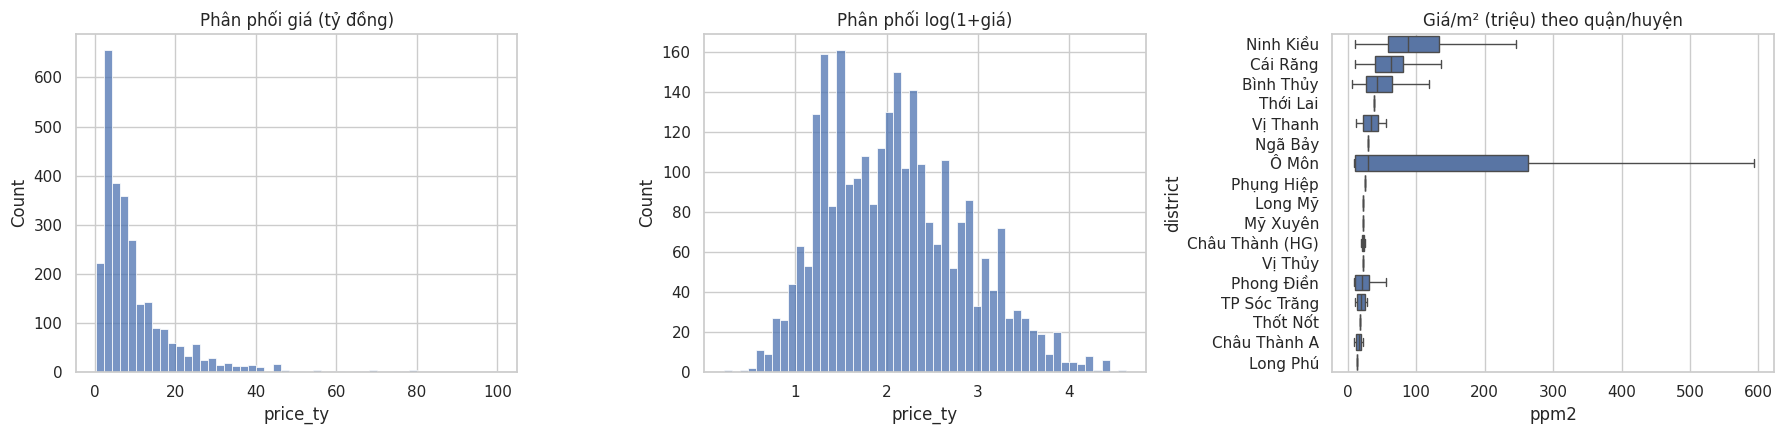

           price_ty   ppm2  area_m2
province                           
Cần Thơ        6.90  75.40    85.00
Hậu Giang      2.20  22.06    90.00
Sóc Trăng      1.88  19.08   101.05


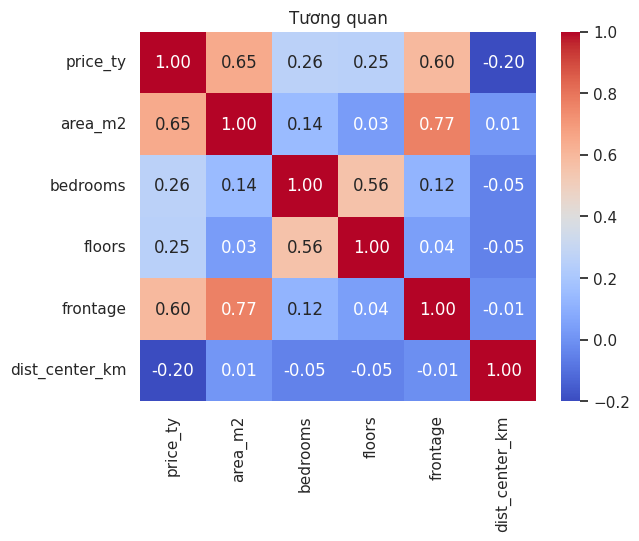

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
sns.histplot(df.price_ty, bins=50, ax=ax[0]); ax[0].set_title("Phân phối giá (tỷ đồng)")
sns.histplot(np.log1p(df.price_ty), bins=50, ax=ax[1]); ax[1].set_title("Phân phối log(1+giá)")
order = df.groupby("district").ppm2.median().sort_values(ascending=False).index
sns.boxplot(data=df, y="district", x="ppm2", order=order, ax=ax[2], showfliers=False)
ax[2].set_title("Giá/m² (triệu) theo quận/huyện")
plt.tight_layout(); plt.show()

print(df.groupby("province")[["price_ty", "ppm2", "area_m2"]].median().round(2))
sns.heatmap(df[["price_ty", "area_m2", "bedrooms", "floors", "frontage", "dist_center_km"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Tương quan"); plt.show()

## Bước 5. Trích xuất đặc trưng văn bản

* **TF-IDF** (unigram + bigram) trên phần mô tả đã làm sạch: phương pháp chính.
* **Word2Vec** (huấn luyện trên chính các tin rao, lấy trung bình vector của từ): dùng để so sánh ở Bước 8.

Toàn bộ nằm trong `Pipeline` nên chỉ `fit` trên tập train.

In [12]:
num_cols = ["area_m2", "log_area", "bedrooms", "floors", "frontage", "lat", "lon", "dist_center_km", "text_len", "n_words"]
cat_cols = ["province", "district", "ward"]
text_col = "text_clean"


class W2VVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=100, window=5, min_count=3, epochs=15):
        self.vector_size, self.window, self.min_count, self.epochs = vector_size, window, min_count, epochs

    def fit(self, X, y=None):
        from gensim.models import Word2Vec
        self.model_ = Word2Vec([s.split() for s in X], vector_size=self.vector_size, window=self.window,
                               min_count=self.min_count, epochs=self.epochs, workers=2, seed=RANDOM_STATE)
        return self

    def transform(self, X):
        wv = self.model_.wv
        out = np.zeros((len(X), self.vector_size))
        for i, s in enumerate(X):
            v = [wv[w] for w in s.split() if w in wv]
            if v:
                out[i] = np.mean(v, axis=0)
        return out


def make_pre(scale=False, text="tfidf"):
    steps = [("imp", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        steps.append(("sc", StandardScaler()))
    if text == "tfidf":
        txt = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.9, max_features=500, sublinear_tf=True)
    else:
        txt = W2VVectorizer()
    return ColumnTransformer([
        ("num", Pipeline(steps), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=10), cat_cols),
        ("txt", txt, text_col)])

## Bước 6. Chia dữ liệu và huấn luyện nhiều mô hình

* Chia 80% train / 20% test.
* Mục tiêu huấn luyện là `log1p(giá tỷ)` (giá lệch phải); khi đánh giá đổi ngược về **tỷ đồng**.
* 4 thuật toán: Linear Regression, Random Forest, XGBoost, LightGBM (yêu cầu tối thiểu 3).

In [13]:
features = num_cols + cat_cols + [text_col]
X = df[features]; y = df["price_ty"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape)

models = {
    "Linear Regression": (LinearRegression(), True),
    "Random Forest": (RandomForestRegressor(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE), False),
    "XGBoost": (XGBRegressor(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
                             tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE), False),
    "LightGBM": (LGBMRegressor(n_estimators=800, learning_rate=0.05, num_leaves=31, subsample=0.8, subsample_freq=1,
                               colsample_bytree=0.8, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1), False),
}

def metrics(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred), "MedAPE %": np.median(np.abs(y_true - y_pred) / y_true) * 100}

fitted, results, preds = {}, [], {}
for name, (est, scale) in models.items():
    t = time.time()
    pipe = Pipeline([("pre", make_pre(scale=scale)), ("model", est)])
    pipe.fit(X_train, np.log1p(y_train))
    p = np.expm1(pipe.predict(X_test))
    fitted[name], preds[name] = pipe, p
    results.append({"Mô hình": name, **metrics(y_test, p), "Thời gian (s)": time.time() - t})
    print("Xong", name)
res = pd.DataFrame(results).set_index("Mô hình").round(3)
res

Train: (2188, 14) Test: (548, 14)
Xong Linear Regression
Xong Random Forest
Xong XGBoost
Xong LightGBM


,RMSE,MAE,R2,MedAPE %,Thời gian (s)
Mô hình,,,,,
Linear Regression,4.309,2.468,0.770,21.463,0.999
Random Forest,4.170,2.276,0.785,15.971,96.456
XGBoost,3.940,2.107,0.808,15.860,56.212
LightGBM,3.841,2.109,0.817,16.429,11.810


## Bước 7. Đánh giá và so sánh (RMSE, MAE, R²)

RMSE và MAE tính theo **tỷ đồng** (càng nhỏ càng tốt), R² càng gần 1 càng tốt. Thêm cross-validation 5-fold (R² trên log giá) để kiểm tra độ ổn định.

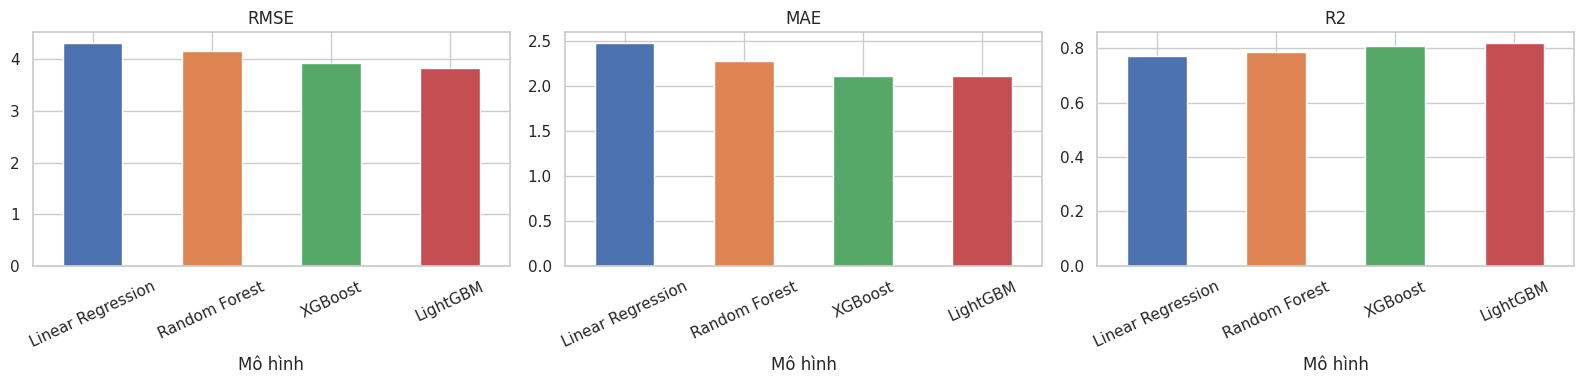

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, m in zip(ax, ["RMSE", "MAE", "R2"]):
    res[m].plot.bar(ax=a, color=sns.color_palette("deep")); a.set_title(m); a.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, (est, scale) in models.items():
    pipe = Pipeline([("pre", make_pre(scale=scale)), ("model", est)])
    s = cross_val_score(pipe, X_train, np.log1p(y_train), cv=cv, scoring="r2")
    cv_rows.append({"Mô hình": name, "CV R2 (log) TB": s.mean(), "Độ lệch chuẩn": s.std()})
pd.DataFrame(cv_rows).set_index("Mô hình").round(3)

In [ ]:
best_name = res["RMSE"].idxmin()
print("Mô hình tốt nhất theo RMSE:", best_name)
p = preds[best_name]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(y_test, p, s=8, alpha=.4); lim = [0, max(y_test.max(), p.max())]
ax[0].plot(lim, lim, "r--"); ax[0].set_xlabel("Giá thực (tỷ)"); ax[0].set_ylabel("Giá dự báo (tỷ)")
ax[0].set_title(f"Thực tế vs dự báo – {best_name}")
sns.histplot(y_test.values - p, bins=50, ax=ax[1]); ax[1].set_title("Phân phối sai số (tỷ)")
plt.tight_layout(); plt.show()

err = pd.DataFrame({"district": X_test["district"].values, "ae": np.abs(y_test.values - p)})
print(err.groupby("district").ae.agg(["count", "mean"]).sort_values("mean").round(3))

## Bước 8. Phân tích, so sánh TF-IDF với Word2Vec, tinh chỉnh và lưu mô hình

In [ ]:
# 8.1 So sánh TF-IDF và Word2Vec (cùng LightGBM)
cmp = []
for tname in ["tfidf", "word2vec"]:
    pipe = Pipeline([("pre", make_pre(scale=False, text=tname)), ("model", LGBMRegressor(
        n_estimators=800, learning_rate=0.05, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1))])
    pipe.fit(X_train, np.log1p(y_train))
    cmp.append({"Đặc trưng văn bản": tname, **metrics(y_test, np.expm1(pipe.predict(X_test)))})
pd.DataFrame(cmp).set_index("Đặc trưng văn bản").round(3)

In [ ]:
# 8.2 Tinh chỉnh LightGBM (RandomizedSearch)
search = RandomizedSearchCV(
    Pipeline([("pre", make_pre()), ("model", LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, subsample_freq=1))]),
    {"model__n_estimators": [300, 600, 1000], "model__learning_rate": [0.02, 0.05, 0.1],
     "model__num_leaves": [15, 31, 63], "model__min_child_samples": [10, 20, 40],
     "model__subsample": [0.7, 0.9, 1.0], "model__colsample_bytree": [0.6, 0.8, 1.0]},
    n_iter=15, cv=3, scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=1)
search.fit(X_train, np.log1p(y_train))
tuned = search.best_estimator_
print("Tham số tốt nhất:", search.best_params_)
print("LightGBM sau tinh chỉnh:", {k: round(v, 3) for k, v in metrics(y_test, np.expm1(tuned.predict(X_test))).items()})

In [ ]:
# 8.3 Độ quan trọng của đặc trưng (LightGBM)
pre = fitted["LightGBM"].named_steps["pre"]
names = pre.get_feature_names_out()
imp = pd.Series(fitted["LightGBM"].named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(25)
imp.iloc[::-1].plot.barh(figsize=(8, 7)); plt.title("Top 25 đặc trưng quan trọng"); plt.tight_layout(); plt.show()

In [ ]:
# 8.4 Hàm dự báo cho một tin mới
def predict_price(model, district, area_m2, bedrooms=np.nan, floors=np.nan, frontage=np.nan,
                  ward="Không rõ", description=""):
    prov, la, lo, _ = LOC[district]
    txt = clean_text(description)
    row = pd.DataFrame([{
        "area_m2": area_m2, "log_area": np.log(area_m2), "bedrooms": bedrooms, "floors": floors, "frontage": frontage,
        "lat": la, "lon": lo, "dist_center_km": float(haversine(CENTER[0], CENTER[1], la, lo)),
        "text_len": len(txt), "n_words": len(txt.split()),
        "province": prov, "district": district, "ward": ward, "text_clean": txt}])
    return float(np.expm1(model.predict(row[features]))[0])

best_pipe = fitted[best_name]
print("Nhà 80m2, Ninh Kiều, 2 tầng, mặt tiền:",
      round(predict_price(best_pipe, "Ninh Kiều", 80, 3, 2, 5, description="nhà mặt tiền đường lớn sổ hồng riêng gần chợ"), 2), "tỷ")
print("Nhà 100m2, TP Sóc Trăng, 1 tầng, hẻm:",
      round(predict_price(best_pipe, "TP Sóc Trăng", 100, 2, 1, 5, description="nhà hẻm xe hơi sổ hồng gần trường học"), 2), "tỷ")

In [ ]:
# 8.5 Lưu mô hình và dữ liệu sạch
import joblib
joblib.dump(best_pipe, "house_price_model.joblib")
df.to_csv("data/clean_listings.csv", index=False)
res.to_csv("data/model_results.csv")
try:
    from google.colab import files
    files.download("house_price_model.joblib"); files.download("data/clean_listings.csv")
except Exception:
    pass

## Bước 9. Web demo cho báo cáo (Gradio)

Chạy **sau khi đã chạy xong Bước 6–8** (cần `best_pipe`, `df`, `res`). Cell cuối sẽ in ra hai đường link:
* `Running on local URL` chỉ dùng trong Colab.
* `Running on public URL: https://xxxx.gradio.live` là link mở được từ trình duyệt bất kỳ (còn sống khoảng 72 giờ, và chỉ khi Colab vẫn đang chạy).

Web có 3 tab: **Dự báo giá**, **Dữ liệu**, **So sánh mô hình**.

In [ ]:
!pip -q install gradio

In [ ]:
import gradio as gr

assert not USING_DEMO, "Đang dùng dữ liệu giả lập. Hãy crawl dữ liệu thật rồi chạy lại từ Bước 2 trước khi mở web."

# Khoảng sai số thực nghiệm (từ tập test) để đưa ra khoảng giá ~80%
rel_err = y_test.values / preds[best_name]
Q10, Q90 = np.quantile(rel_err, [0.1, 0.9])
districts = df["district"].value_counts().index.tolist()

def _nan(x):
    return np.nan if x in (None, "") else float(x)

def du_bao(district, area, bedrooms, floors, frontage, desc):
    if area is None or area <= 0:
        return "Vui lòng nhập diện tích hợp lệ (m²).", None
    p = predict_price(best_pipe, district, float(area), _nan(bedrooms), _nan(floors), _nan(frontage),
                      description=desc or "")
    sub = df[df.district == district]
    ppm = p * 1000 / float(area)
    text = (f"### Giá dự báo: **{p:.2f} tỷ đồng**\n"
            f"- Khoảng giá (~80%): **{p * Q10:.2f} – {p * Q90:.2f} tỷ**\n"
            f"- Đơn giá: {ppm:.1f} triệu/m² (trung vị của {district}: {sub.ppm2.median():.1f} triệu/m²)\n"
            f"- Mô hình sử dụng: {best_name} | Số tin tham chiếu tại khu vực: {len(sub)}")
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(sub.price_ty.clip(upper=sub.price_ty.quantile(0.98)), bins=30, color="#9ecae1")
    ax.axvline(p, color="red", lw=2, label=f"Dự báo: {p:.2f} tỷ")
    ax.set_title(f"Phân phối giá nhà tại {district}"); ax.set_xlabel("Giá (tỷ đồng)"); ax.set_ylabel("Số tin")
    ax.legend(); fig.tight_layout(); plt.close(fig)
    return text, fig

def fig_data():
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    df.groupby("district").ppm2.median().sort_values().plot.barh(ax=ax[0], color="#6baed6")
    ax[0].set_title("Giá/m² trung vị theo quận/huyện (triệu đồng)")
    df["province"].value_counts().plot.bar(ax=ax[1], color="#74c476"); ax[1].tick_params(axis="x", rotation=0)
    ax[1].set_title(f"Số tin theo tỉnh (tổng {len(df)})")
    fig.tight_layout(); plt.close(fig)
    return fig

def fig_models():
    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    for a, m in zip(ax, ["RMSE", "MAE", "R2"]):
        res[m].plot.bar(ax=a, color="#fd8d3c"); a.set_title(m); a.tick_params(axis="x", rotation=25)
    fig.tight_layout(); plt.close(fig)
    return fig

with gr.Blocks(title="Dự báo giá nhà Cần Thơ - Hậu Giang - Sóc Trăng") as demo:
    gr.Markdown("# Hệ thống dự báo giá nhà từ tin rao vặt\n"
                f"Khu vực: **Cần Thơ – Hậu Giang – Sóc Trăng** | Dữ liệu: **{len(df)} tin rao thật** từ Chợ Tốt | "
                "Mô hình: TF-IDF + LightGBM/XGBoost/Random Forest/Linear Regression")
    with gr.Tab("Dự báo giá"):
        with gr.Row():
            with gr.Column():
                in_dist = gr.Dropdown(choices=districts, value=districts[0], label="Quận/Huyện")
                in_area = gr.Number(value=80, label="Diện tích (m²)")
                in_bed = gr.Number(value=3, label="Số phòng ngủ (để trống nếu không rõ)")
                in_floor = gr.Number(value=2, label="Số tầng (để trống nếu không rõ)")
                in_front = gr.Number(value=5, label="Chiều rộng mặt tiền (m)")
                in_desc = gr.Textbox(lines=4, label="Mô tả tin rao",
                                     value="Nhà mặt tiền đường lớn, sổ hồng riêng, gần chợ, trường học")
                btn = gr.Button("Dự báo giá", variant="primary")
            with gr.Column():
                out_text = gr.Markdown()
                out_plot = gr.Plot(label="So sánh với giá thị trường tại khu vực")
        btn.click(du_bao, [in_dist, in_area, in_bed, in_floor, in_front, in_desc], [out_text, out_plot])
    with gr.Tab("Dữ liệu"):
        gr.Plot(value=fig_data())
    with gr.Tab("So sánh mô hình"):
        gr.Dataframe(value=res.reset_index(), label="Kết quả trên tập test (RMSE, MAE: tỷ đồng)")
        gr.Plot(value=fig_models())

demo.launch(share=True, debug=False)

## Gợi ý viết báo cáo

1. **Dữ liệu:** nguồn, số tin crawl, số tin sau làm sạch, phân bố theo tỉnh/quận.
2. **Tiền xử lý:** regex trích xuất, tỉ lệ thiếu, cách xử lý outlier, chống rò rỉ giá trong văn bản, chuẩn hóa địa chỉ.
3. **Mô hình:** bảng RMSE/MAE/R² (Bước 6–7), CV, so sánh TF-IDF và Word2Vec, kết quả tinh chỉnh.
4. **Phân tích lỗi:** quận/huyện nào dự báo kém (thường là nơi ít dữ liệu), hạn chế (giá rao ≠ giá giao dịch, tọa độ chỉ ở mức quận/huyện).
5. **Hướng phát triển:** geocoding chi tiết, PhoBERT embedding, thêm dữ liệu theo thời gian.